<a href="https://colab.research.google.com/github/avionerman/AML/blob/main/03_causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Causal AI Gold-Pattern Gate

**Ιδεα:** Το closed-set classifier μαθαινει **συσχετισεις**. Ενας adversarial
attacker μπορει να φτιαξει spectrogram που σταθερα classify-αρεται ως φιλικο
χωρις να εχει τα πραγματικα φυσικα χαρακτηριστικα του drone.

**Η λυση μας:** Ενα **ensemble απο 5 post-hoc causal/concept gates** που ελεγχουν
αν τα "gold patterns" ενος φιλικου drone υπαρχουν πραγματικα στο sample. Καθε
gate πρεπει να συμφωνησει για να γινει accept.

| # | Gate | Domain | Reference |
| --- | --- | --- | --- |
| 1 | PCBM | feature-space concept activations | Yuksekgonul et al., ICLR 2023 (Stanford) |
| 2 | CAR | kernel SVMs on feature space | Crabbé & van der Schaar, NeurIPS 2022 (Cambridge) |
| 3 | CRP (or Grad-CAM fallback) | spatial relevance map | Achtibat et al., Nature MI 2023 |
| 4 | CaCE | causal effect audit | Goyal et al., DeepMind 2019/2020 |
| 5 | RF-DSP gold patterns | classical signal processing on x_iq | (in-house) |

**Cost matrix:** unbiased — κανουμε sweep ολα τα thresholds και αφηνουμε εσας
να επιλεξετε το operating point ΜΕΤΑ απο τη μετρηση.


## 1. Setup

In [7]:
# Auto-detect environment (Colab vs local) and add src/ to sys.path.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/drive/MyDrive/rf_drone_defense")
else:
    # local: this notebook lives in <root>/notebooks/, src/ is one level up
    PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(PROJECT))
print("Project root:", PROJECT)
print("Python:", sys.version.split()[0])

import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/rf_drone_defense
Python: 3.12.13
torch 2.10.0+cu128 | CUDA available: True
GPU: NVIDIA L4


In [8]:
from src.config import CFG, CLASS_NAMES, FRIENDLY_IDX, NOISE_IDX, N_CLASSES
from src import data as data_mod
from src import model as model_mod
from src import causal as causal_mod
from src import metrics as metrics_mod

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


### 1.1 Επιλογη variant του εκπαιδευμενου μοντελου

Το notebook 01 παραγει **δυο εκδοχες** μοντελου (αν εχετε τρεξει και τα δυο passes):

- `artefacts/01_training_clean/`  → clean baseline (PGD off)
- `artefacts/01_training_pgd/`    → PGD-hardened

Διαλεξτε ποια θελετε να αναλυσετε αλλαζοντας **μια γραμμη** στο cell παρακατω.


In [9]:
# === Επιλογη μοντελου προς αναλυση ===
# False -> διαβαζει απο artefacts/01_training_clean/
# True  -> διαβαζει απο artefacts/01_training_pgd/
CFG.use_adversarial_training = False

print(f"Reading artefacts from: {CFG.artefacts('01_training')}")
assert CFG.artefacts('01_training').exists(), (
    f"Folder missing: {CFG.artefacts('01_training')}. "
    "Have you run 01_training.ipynb for this variant yet?"
)


Reading artefacts from: /content/drive/MyDrive/rf_drone_defense/artefacts/01_training_clean


## 2. Φορτωση artefacts απο το 01_training

In [10]:
art01 = CFG.artefacts("01_training")
tr_emb = np.load(art01 / "embeddings_train.npz")
va_emb = np.load(art01 / "embeddings_val.npz")
te_emb = np.load(art01 / "embeddings_test.npz")

print("train features:", tr_emb["features"].shape)
print("val features:  ", va_emb["features"].shape)
print("test features: ", te_emb["features"].shape)


train features: (68992, 512)
val features:   (14806, 512)
test features:  (14806, 512)


## 3. PCBM — Concept Bottleneck στο feature space

In [11]:
pcbm = causal_mod.fit_pcbm(
    train_features=tr_emb["features"],
    train_labels=tr_emb["y"],
    n_concepts_per_class=CFG.pcbm_n_concepts_per_class,
    only_friendly=True,
)
print(f"Total concept vectors: {pcbm.total_concepts}")
print(f"Concept vector shape:  {pcbm.concept_vectors.shape}")

pcbm_test = causal_mod.pcbm_score(pcbm, te_emb["features"], te_emb["preds"])
print(f"PCBM scores  range: [{pcbm_test.min():.3f}, {pcbm_test.max():.3f}]")


Total concept vectors: 56
Concept vector shape:  (7, 8, 512)
PCBM scores  range: [0.000, 4195.399]


## 4. CAR — Kernel SVMs ανα concept

In [12]:
car = causal_mod.fit_car(tr_emb["features"], tr_emb["y"], pcbm, kernel=CFG.car_kernel, only_friendly=True)
print(f"Fitted {len(car.svms)} (class, concept) SVMs")

car_test = causal_mod.car_score(car, te_emb["features"], te_emb["preds"])
print(f"CAR scores  range: [{car_test.min():.3f}, {car_test.max():.3f}]")


Fitted 48 (class, concept) SVMs
CAR scores  range: [-0.888, 4.609]


## 5. CRP — Spatial relevance (or Grad-CAM fallback)

In [13]:
# We need the model itself for Grad-CAM / CRP — load checkpoint.
model = model_mod.build_model(N_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(art01 / "checkpoints" / "best.pt",
                                 map_location=DEVICE, weights_only=True))
model.eval()

# Rebuild loaders to access raw spectrograms.
pack = data_mod.load_arrays(CFG.dataset_path, with_iq=False)
x_spec, y, snr = pack["x_spec"], pack["y"], pack["snr"]
splits = np.load(art01 / "splits.npz")
train_idx, val_idx, test_idx = splits["train"], splits["val"], splits["test"]
_, val_loader, test_loader = data_mod.make_loaders(
    (train_idx, val_idx, test_idx), x_spec, y, snr, cfg=CFG, augment_train=False,
)

# 5.1 — learn "expected relevance regions" per friendly class on TRAIN
print("Computing expected relevance regions per friendly class…")
train_loader, _, _ = data_mod.make_loaders(
    (train_idx, val_idx, test_idx), x_spec, y, snr, cfg=CFG, augment_train=False,
)
regions = causal_mod.fit_expected_regions(model, train_loader, DEVICE, n_per_class=64)
print(f"Built {len(regions)} class regions")


Computing expected relevance regions per friendly class…
Built 6 class regions


In [14]:
# 5.2 — score every test sample
crp_scores_list = []
model.eval()
with torch.set_grad_enabled(True):
    for xb, yb, _ in test_loader:
        xb = xb.to(DEVICE)
        preds_t = torch.as_tensor(te_emb["preds"][len(crp_scores_list) * CFG.batch_size:
                                                 len(crp_scores_list) * CFG.batch_size + xb.shape[0]],
                                  device=DEVICE)
        s = causal_mod.crp_score(model, xb, preds_t, expected_regions=regions)
        crp_scores_list.append(s.cpu().numpy())
crp_test = np.concatenate(crp_scores_list)
print(f"CRP scores  range: [{crp_test.min():.3f}, {crp_test.max():.3f}]")


CRP scores  range: [0.088, 1.000]


## 6. CaCE — Causal effect audit ανα concept

In [15]:
print("pcbm.classifier_W.shape:", pcbm.classifier_W.shape)
print("pcbm.classifier_b.shape:", pcbm.classifier_b.shape)
print("pcbm.concept_vectors.shape:", pcbm.concept_vectors.shape)
print("tr_emb['features'].shape:", tr_emb["features"].shape)


pcbm.classifier_W.shape: (7, 56)
pcbm.classifier_b.shape: (7,)
pcbm.concept_vectors.shape: (7, 8, 512)
tr_emb['features'].shape: (68992, 512)


In [16]:
# CaCE is offline diagnostic — runs on train features.
cace = causal_mod.cace_audit(
    pcbm,
    features=tr_emb["features"],
    labels=tr_emb["y"],
    model_predict_fn=None,  # unused — PCBM logreg is consulted internally
)
# Print effects sorted per class.
for c in FRIENDLY_IDX:
    effs = cace[c]
    sorted_k = sorted(effs.items(), key=lambda kv: -kv[1])
    top = ", ".join([f"k{k}: ΔP={v:+.4f}" for k, v in sorted_k[:3]])
    print(f"{CLASS_NAMES[c]:>10}  top-3 concepts: {top}")


       DJI  top-3 concepts: k1: ΔP=+0.0345, k3: ΔP=+0.0314, k0: ΔP=+0.0042
 FutabaT14  top-3 concepts: k4: ΔP=+0.3178, k2: ΔP=+0.0767, k0: ΔP=+0.0413
  FutabaT7  top-3 concepts: k6: ΔP=+0.0495, k3: ΔP=+0.0328, k0: ΔP=+0.0144
  Graupner  top-3 concepts: k3: ΔP=+0.0662, k7: ΔP=+0.0296, k2: ΔP=+0.0164
   Taranis  top-3 concepts: k2: ΔP=+0.3747, k7: ΔP=+0.2613, k1: ΔP=+0.2366
   Turnigy  top-3 concepts: k1: ΔP=+0.4604, k0: ΔP=+0.0858, k3: ΔP=+0.0703


**Σχολιο:** Concepts με ΔP κοντα στο 0 ειναι correlational, οχι causal — δεν
αξιζουν να ειναι μερος του gold pattern set. Πρακτικα μπορουμε να τα αφαιρεσουμε
απο το PCBM/CAR εαν θελουμε pure-causal gate.


## 7. RF-DSP Gold Patterns (multi-modal — απαιτει x_iq)

In [18]:
import gc, torch

# Free pack + loaders to make room for x_iq
for _name in ("pack", "x_spec", "train_loader", "val_loader", "test_loader"):
    if _name in dir():
        del globals()[_name]
gc.collect()

print("Loading dataset.pt to extract x_iq…")
_data = torch.load(CFG.dataset_path, map_location="cpu", weights_only=False)
x_iq_all = _data["x_iq"]
del _data
gc.collect()
print("x_iq loaded:", x_iq_all.shape, "dtype:", x_iq_all.dtype)

# Build gold patterns on a stratified TRAIN sub-sample.
rng = np.random.default_rng(CFG.seed)
n_per_class = 200
train_y_arr = tr_emb["y"]
train_idx_aligned = train_idx[: len(train_y_arr)]
sample_idx = []
for c in FRIENDLY_IDX:
    cls_idx = train_idx_aligned[train_y_arr == c]
    if len(cls_idx) == 0:
        continue
    take = min(n_per_class, len(cls_idx))
    sample_idx.append(rng.choice(cls_idx, size=take, replace=False))
sample_idx = np.concatenate(sample_idx)
print(f"Fitting RF gold patterns on {len(sample_idx)} TRAIN samples…")
x_iq_train_sub = x_iq_all[sample_idx].numpy()
y_train_sub = y[sample_idx].numpy()
rf_patterns = causal_mod.fit_rf_gold_patterns(x_iq_train_sub, y_train_sub)
print("Built RF gold patterns for classes:", sorted(rf_patterns.feature_means.keys()))


Loading dataset.pt to extract x_iq…
x_iq loaded: torch.Size([98705, 2, 16384]) dtype: torch.float32
Fitting RF gold patterns on 1200 TRAIN samples…
Built RF gold patterns for classes: [0, 1, 2, 3, 5, 6]


In [19]:
# Score every test sample with RF-DSP gold patterns.
print(f"Scoring {len(test_idx)} test samples on RF-DSP gold patterns…")
x_iq_test = x_iq_all[test_idx].numpy()
rf_test = causal_mod.rf_score(rf_patterns, x_iq_test, te_emb["preds"])
print(f"RF scores  range: [{rf_test.min():.3f}, {rf_test.max():.3f}]")


Scoring 14806 test samples on RF-DSP gold patterns…
RF scores  range: [-1000000000.000, -0.753]


## 8. Ensemble — combine πεντε scores

In [20]:
ensemble = causal_mod.causal_ensemble_score(pcbm_test, car_test, crp_test, rf_test,
                                            weights=(1.0, 1.0, 1.0, 1.0))
print(f"Ensemble score range: [{ensemble.min():.3f}, {ensemble.max():.3f}]")


Ensemble score range: [-4.144, 9.405]


## 9. Unbiased Cost Matrix Evaluation

In [21]:
# y_test is the raw class — evaluate_gate computes friend/foe internally.
gate_eval = metrics_mod.evaluate_gate(ensemble, te_emb["y"])
print(f"Ensemble ROC AUC (friend vs foe): {gate_eval.roc_auc:.4f}")

# Pick a threshold at 1:1 cost as the demo. The user can change these.
tau, mtr = gate_eval.pick_threshold(cost_fp=1.0, cost_fn=1.0)
print(__import__("json").dumps(mtr, indent=2))


Ensemble ROC AUC (friend vs foe): 0.9454
{
  "tau": -1.7301777601242065,
  "fpr": 0.03448713072144034,
  "fnr": 0.09538950715421302,
  "tpr": 0.904610492845787,
  "tnr": 0.9655128692785596,
  "cost": 0.12987663787565334
}


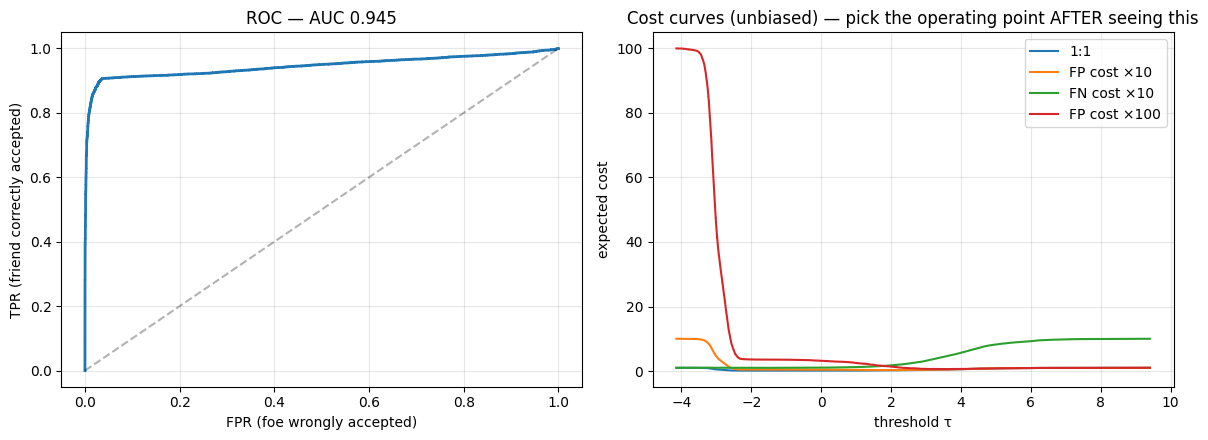

In [22]:
# Plot ROC + cost curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ROC
axes[0].plot(gate_eval.fpr, gate_eval.tpr, lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR (foe wrongly accepted)"); axes[0].set_ylabel("TPR (friend correctly accepted)")
axes[0].set_title(f"ROC — AUC {gate_eval.roc_auc:.3f}")
axes[0].grid(alpha=0.3)

# Cost vs threshold for several cost ratios
for cfp, cfn, name in [(1, 1, "1:1"), (10, 1, "FP cost ×10"), (1, 10, "FN cost ×10"), (100, 1, "FP cost ×100")]:
    cost = cfp * gate_eval.fpr + cfn * gate_eval.fnr
    axes[1].plot(gate_eval.thresholds, cost, label=name)
axes[1].set_xlabel("threshold τ"); axes[1].set_ylabel("expected cost")
axes[1].set_title("Cost curves (unbiased) — pick the operating point AFTER seeing this")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.figures("03_causal") / "roc_and_cost_curves.png", dpi=120)
plt.show()


### 9.1 Hard 2×2 cost matrix at chosen τ

In [23]:
y_friend_true = metrics_mod.friend_label(te_emb["y"])
y_friend_pred = (ensemble >= tau).astype(np.int64)
cm22 = metrics_mod.cost_matrix_2x2(y_friend_true, y_friend_pred)
print("Hard 2x2 at τ=", f"{tau:.4f}", ":", cm22)

fp_rate = cm22["fp"] / max(1, cm22["fp"] + cm22["tn"])
fn_rate = cm22["fn"] / max(1, cm22["fn"] + cm22["tp"])
print(f"FP rate (foe slipped):   {fp_rate*100:.2f}%")
print(f"FN rate (friend rejected): {fn_rate*100:.2f}%")


Hard 2x2 at τ= -1.7302 : {'tp': 6259, 'tn': 7615, 'fp': 272, 'fn': 660}
FP rate (foe slipped):   3.45%
FN rate (friend rejected): 9.54%


## 10. Persistence

In [24]:
import json
out = CFG.artefacts("03_causal")
torch.save({
    "pcbm_concept_vectors": pcbm.concept_vectors,
    "pcbm_classifier_W": pcbm.classifier_W,
    "pcbm_classifier_b": pcbm.classifier_b,
    "feat_scaler_mean": pcbm.feat_scaler.mean_,
    "feat_scaler_scale": pcbm.feat_scaler.scale_,
    "rf_patterns_means": rf_patterns.feature_means,
    "rf_patterns_inv_cov": rf_patterns.feature_inv_cov,
    "rf_feature_names": rf_patterns.feature_names,
    "tau_at_1to1": float(tau),
    "ood_auroc_ensemble": float(gate_eval.roc_auc),
}, out / "gold_patterns.pt")

np.savez_compressed(out / "scores_test.npz",
    pcbm=pcbm_test, car=car_test, crp=crp_test, rf=rf_test, ensemble=ensemble,
    y=te_emb["y"], snr=te_emb["snr"], preds=te_emb["preds"],
)

with (out / "cost_matrix.json").open("w", encoding="utf-8") as f:
    json.dump({
        "tau_at_1to1": float(tau),
        "metrics_at_1to1": mtr,
        "ood_auroc_ensemble": float(gate_eval.roc_auc),
        "hard_2x2": cm22,
        "cace_effects": {int(k): v for k, v in cace.items()},
    }, f, indent=2, default=str)
print("Saved:", out)


Saved: /content/drive/MyDrive/rf_drone_defense/artefacts/03_causal_clean
